# 2D Bond Percolation Simulation with Union-Find

In this guide, we demonstrate how to generate finite-size scaling dataset for the **two-dimensional bond percolation** problem from scratch using the **Union-Find (Disjoint Set Union)** algorithm.

By the end of this tutorial, you will have a clear understanding of:
1. How bond percolation is simulated on a square lattice.
2. How the Union-Find algorithm efficiently tracks connected clusters.
3. How to measure the truncated mean cluster size (cluster susceptibility) $\chi^{\mathrm{f}}(p, L)$.
4. How to format and save the simulation results for analysis with `jaxfss`.

## 1. Theoretical Background

Consider a square lattice of linear dimension $L$ containing $N = L^2$ sites. In bond percolation:
* Each edge (bond) between adjacent sites is occupied independently with probability $p \in [0, 1]$.
* Connected sites form **clusters**.
* At the critical probability $p_{\mathrm{c}} = 1/2 = 0.5$, an infinite (spanning) cluster emerges in the thermodynamic limit $L \to \infty$.

To perform finite-size scaling analysis, we measure the **truncated mean cluster size** (also known as finite cluster susceptibility) $\chi^{\mathrm{f}}(p, L)$, which excludes the largest cluster $s_{\max}$:

$$
\chi^{\mathrm{f}}(p, L) = \frac{1}{L^2} \sum_{c \neq c_{\max}} s_c^2
$$

where $s_c$ is the number of sites in cluster $c$. Near $p_{\mathrm{c}}$, $\chi^{\mathrm{f}}$ satisfies the scaling relation:

$$
\chi^{\mathrm{f}}(p, L) = L^{\gamma/\nu} F\left[ (p - p_{\mathrm{c}}) L^{1/\nu} \right]
$$

with exact 2D exponents $c_1 = 1/\nu = 3/4 = 0.75$ and $c_2 = -\gamma/\nu = -43/24 \approx -1.79167$ (or $-7/4 = -1.75$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import jaxfss

## 2. The Union-Find (Disjoint Set Union) Algorithm

The Union-Find data structure maintains a collection of disjoint sets. With **path compression** in `find` and **union by size** in `union`, nearly all operations run in nearly $\mathcal{O}(1)$ amortized time (inverse Ackermann complexity $\mathcal{O}(\alpha(N))$).

In [2]:
class DisjointSet:
    """Union-Find data structure with path compression and union by size."""
    def __init__(self, n: int):
        self.parent = list(range(n))
        self.size = [1] * n

    def find(self, i: int) -> int:
        path = []
        while self.parent[i] != i:
            path.append(i)
            i = self.parent[i]
        for node in path:
            self.parent[node] = i
        return i

    def union(self, i: int, j: int) -> bool:
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            # Union by size: attach smaller cluster to larger cluster
            if self.size[root_i] < self.size[root_j]:
                root_i, root_j = root_j, root_i
            self.parent[root_j] = root_i
            self.size[root_i] += self.size[root_j]
            return True
        return False

def get_square_lattice_bonds(L: int) -> np.ndarray:
    """Generate all nearest-neighbor pairs (edges) on an L x L open-boundary grid."""
    bonds = []
    for x in range(L):
        for y in range(L):
            idx = x * L + y
            if x + 1 < L:
                bonds.append((idx, (x + 1) * L + y))
            if y + 1 < L:
                bonds.append((idx, x * L + (y + 1)))
    return np.array(bonds, dtype=np.int32)

## 3. Visualizing Cluster Configurations

Let us visualize cluster formation on an $L = 32$ lattice at three representative bond probabilities:
1. **Subcritical ($p = 0.40$)**: Only small, localized clusters exist.
2. **Critical ($p = 0.50$)**: Fractal clusters with power-law size distribution appear.
3. **Supercritical ($p = 0.60$)**: A giant spanning cluster covers most of the system.

<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/var/folders/g6/3yjn6zvx14s3q4k28w8d78fw0000gn/T/ipykernel_2365/2135695765.py:34: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"{title}\n$s_{{\max}} = {s_max} / {L_vis**2}$", fontsize=11)


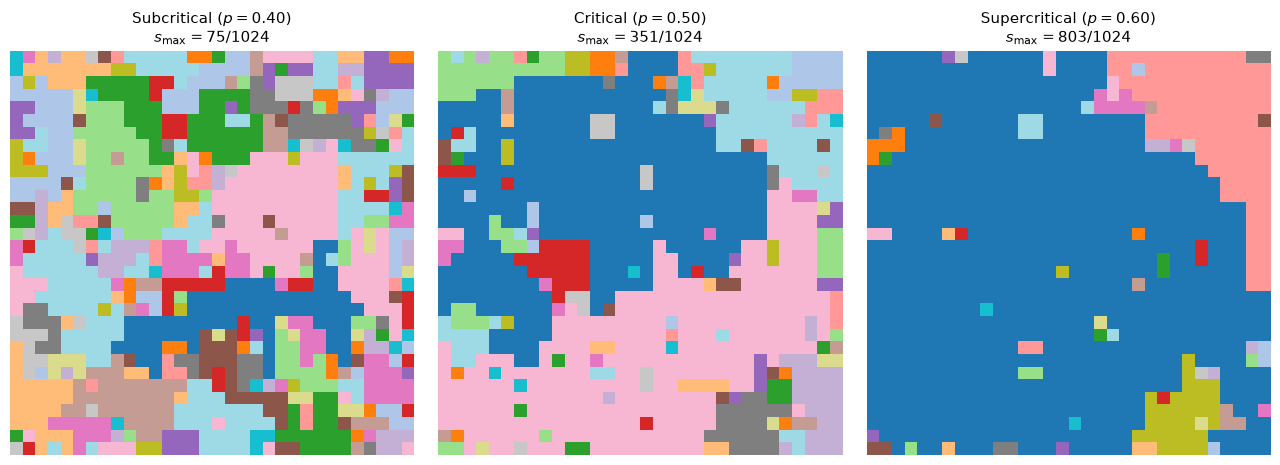

In [3]:
def get_cluster_grid(L: int, p: float, seed: int = 0):
    rng = np.random.default_rng(seed)
    bonds = get_square_lattice_bonds(L)
    active_bonds = bonds[rng.random(len(bonds)) < p]
    
    N = L * L
    uf = DisjointSet(N)
    for u, v in active_bonds:
        uf.union(u, v)
        
    root_ids = [uf.find(i) for i in range(N)]
    # Map each root to cluster size
    sizes = np.array([uf.size[r] for r in root_ids])
    max_root = root_ids[np.argmax(sizes)]
    
    # Assign unique visual color IDs (reserve -1 for largest cluster)
    unique_roots = list(set(root_ids))
    rng.shuffle(unique_roots)
    root_to_color = {r: (i % 20 + 1) for i, r in enumerate(unique_roots)}
    root_to_color[max_root] = 0  # largest cluster highlighted
    
    grid = np.array([root_to_color[r] for r in root_ids]).reshape(L, L)
    return grid, uf.size[max_root]

L_vis = 32
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
probabilities = [0.40, 0.50, 0.60]
titles = ["Subcritical ($p = 0.40$)", "Critical ($p = 0.50$)", "Supercritical ($p = 0.60$)"]

for ax, p_val, title in zip(axes, probabilities, titles):
    grid, s_max = get_cluster_grid(L_vis, p_val, seed=42)
    # Plot clusters with largest cluster colored distinctly
    ax.imshow(grid, cmap="tab20", origin="lower", interpolation="nearest")
    ax.set_title(rf"{title}\n$s_{{\max}} = {s_max} / {L_vis**2}$", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Measuring Cluster Susceptibility $\chi^{\mathrm{f}}(p, L)$

We simulate multiple random bond realizations for given system size $L$ and occupation probability $p$, calculating the mean and standard error of $\chi^{\mathrm{f}}$.

In [4]:
def sample_susceptibility(L: int, p: float, n_samples: int = 100, rng: np.random.Generator = None) -> tuple[float, float]:
    """Compute the truncated mean cluster size chi^f(p, L) averaged over n_samples."""
    if rng is None:
        rng = np.random.default_rng()
    N = L * L
    bonds = get_square_lattice_bonds(L)
    n_bonds = len(bonds)
    
    chis = []
    for _ in range(n_samples):
        active = bonds[rng.random(n_bonds) < p]
        uf = DisjointSet(N)
        for u, v in active:
            uf.union(u, v)
            
        roots = set(uf.find(i) for i in range(N))
        sizes = sorted([uf.size[r] for r in roots], reverse=True)
        # Exclude largest cluster s_max
        finite_sizes = sizes[1:] if len(sizes) > 1 else [0]
        chi_val = sum(s * s for s in finite_sizes) / N
        chis.append(chi_val)
        
    chis = np.array(chis)
    mean = np.mean(chis)
    std_err = np.std(chis, ddof=1) / np.sqrt(n_samples)
    return float(mean), float(std_err)

Now, we run the simulation across different system sizes $L \in \{16, 32, 64\}$ over a grid of $p$ around $p_{\mathrm{c}} = 0.5$.

In [5]:
system_sizes = [16, 32, 64]
p_values = np.linspace(0.35, 0.65, 21)
n_samples = 120
rng = np.random.default_rng(2026)

sim_results = {}
print(f"Running percolation simulation for L in {system_sizes}...")
t_start = time.time()

for L in system_sizes:
    means, errs = [], []
    for p in p_values:
        m, e = sample_susceptibility(L, p, n_samples=n_samples, rng=rng)
        means.append(m)
        errs.append(e)
    sim_results[L] = (np.array(means), np.array(errs))
    print(f"  L = {L:2d} completed in {time.time() - t_start:.2f}s (peak chi = {max(means):.2f})")

print(f"Total simulation time: {time.time() - t_start:.2f}s")

Running percolation simulation for L in [16, 32, 64]...


  L = 16 completed in 0.65s (peak chi = 11.31)


  L = 32 completed in 3.55s (peak chi = 34.09)


  L = 64 completed in 15.64s (peak chi = 115.18)
Total simulation time: 15.64s


Plot the generated cluster susceptibility curves $\chi^{\mathrm{f}}(p, L)$.

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/var/folders/g6/3yjn6zvx14s3q4k28w8d78fw0000gn/T/ipykernel_2365/328540323.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(0.5, color="black", linestyle=":", label="Exact $p_{\mathrm{c}} = 0.5$")


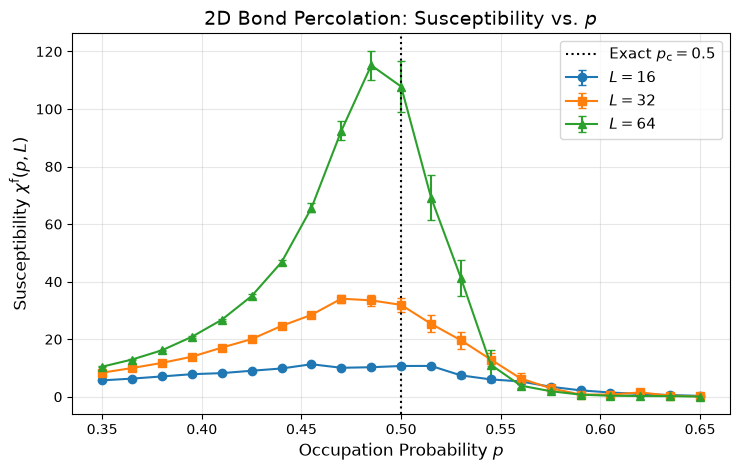

In [6]:
plt.figure(figsize=(7.5, 4.8))
markers = ["o", "s", "^"]

for (L, (means, errs)), m in zip(sim_results.items(), markers):
    plt.errorbar(p_values, means, yerr=errs, fmt=f"{m}-", label=f"$L = {L}$", capsize=3, lw=1.5)

plt.axvline(0.5, color="black", linestyle=":", label="Exact $p_{\mathrm{c}} = 0.5$")
plt.xlabel(r"Occupation Probability $p$", fontsize=12)
plt.ylabel(r"Susceptibility $\chi^{\mathrm{f}}(p, L)$", fontsize=12)
plt.title("2D Bond Percolation: Susceptibility vs. $p$", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Notice how:
1. The peak location steadily approaches the theoretical critical point $p_{\mathrm{c}} = 0.50$ as $L$ increases.
2. The peak height grows rapidly as $L^{\gamma/\nu} = L^{1.75}$.

## 5. Exporting Dataset for `jaxfss`

`jaxfss.CriticalData.from_file` expects white-space delimited tabular data with 4 columns:
```
system_size  temperature/probability  observable  observable_error
```

We format our simulation results into this structure and verify loading with `jaxfss`.

In [7]:
output_rows = []
for L, (means, errs) in sim_results.items():
    for p, val, err in zip(p_values, means, errs):
        output_rows.append([L, p, val, err])

output_data = np.array(output_rows)
output_path = "percolation_custom.txt"

# Save to file with exact format
np.savetxt(
    output_path,
    output_data,
    fmt=["%d", "%.8f", "%.8f", "%.8f"],
    header="L p chi_f chi_f_err"
)
print(f"Saved {len(output_data)} rows to {output_path}.")

# Verify loading with jaxfss
loaded_dataset = jaxfss.CriticalData.from_file(output_path)
print(f"Successfully loaded into jaxfss: {loaded_dataset}")
print(f"System sizes in dataset: {np.unique(loaded_dataset.Ls)}")

Saved 63 rows to percolation_custom.txt.


Successfully loaded into jaxfss: jaxfss.CriticalData(n_data=63)
System sizes in dataset: [16. 32. 64.]


## Summary

We have implemented the Union-Find algorithm for 2D bond percolation, simulated cluster susceptibility across multiple lattice sizes, and exported the data directly for finite-size scaling analysis in `jaxfss`.